<a href="https://colab.research.google.com/github/dindahanifa/mechine_learning/blob/main/Jantung.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# =====================================
# 🚀 Percepatan & Pengukuran Eksekusi
# =====================================

# 1️⃣ --- Cek apakah GPU aktif di Colab ---
import os
gpu_info = os.popen('nvidia-smi').read()
if "failed" in gpu_info:
    print("⚠️ GPU belum aktif. Aktifkan via Runtime > Change runtime type > GPU")
else:
    print("✅ GPU aktif dan siap dipakai!")
    print(gpu_info.split('\n')[0])

# 2️⃣ --- Cara 1: Pakai %%time (khusus untuk cell di Colab) ---
# Jalankan ini di satu cell Colab terpisah:
# %%time
# for i in range(10_000_000):
#     _ = i ** 2

# 3️⃣ --- Cara 2: Pakai time.time() manual ---
import time

print("\n⏱️ Mengukur waktu dengan time.time() ...")
start = time.time()
for i in range(10_000_000):
    _ = i ** 2
end = time.time()
print(f"Waktu eksekusi loop biasa: {end - start:.3f} detik")

# 4️⃣ --- Cara 3: Pakai Numba (JIT Compiler) untuk mempercepat Python loop ---
from numba import njit

@njit
def fast_loop(n=10_000_000):
    total = 0
    for i in range(n):
        total += i ** 2
    return total

print("\n⚡ Mengukur waktu dengan Numba (JIT Compilation)...")
start = time.time()
fast_loop()  # pertama kali akan kompilasi (lebih lambat)
end = time.time()
print(f"Pertama kali (kompilasi): {end - start:.3f} detik")

start = time.time()
fast_loop()  # eksekusi berikutnya super cepat
end = time.time()
print(f"Eksekusi berikutnya: {end - start:.3f} detik")

# 5️⃣ --- Cara 4: Gunakan operasi vectorized (NumPy) ---
import numpy as np

print("\n⚙️ Mengukur waktu dengan operasi vectorized NumPy ...")
start = time.time()
x = np.arange(10_000_000)
y = x ** 2  # super cepat tanpa loop manual
end = time.time()
print(f"Waktu eksekusi NumPy: {end - start:.3f} detik")

# 6️⃣ --- Bonus: Decorator otomatis untuk mengukur waktu fungsi ---
def timed(func):
    def wrapper(*args, **kwargs):
        start = time.time()
        result = func(*args, **kwargs)
        end = time.time()
        print(f"⏰ Fungsi '{func.__name__}' selesai dalam {end - start:.3f} detik")
        return result
    return wrapper

@timed
def contoh_fungsi():
    s = 0
    for i in range(5_000_000):
        s += i ** 2
    return s

print("\n🧩 Contoh fungsi dengan decorator otomatis:")
contoh_fungsi()

✅ GPU aktif dan siap dipakai!


⏱️ Mengukur waktu dengan time.time() ...
Waktu eksekusi loop biasa: 3.157 detik

⚡ Mengukur waktu dengan Numba (JIT Compilation)...
Pertama kali (kompilasi): 5.092 detik
Eksekusi berikutnya: 0.000 detik

⚙️ Mengukur waktu dengan operasi vectorized NumPy ...
Waktu eksekusi NumPy: 0.222 detik

🧩 Contoh fungsi dengan decorator otomatis:
⏰ Fungsi 'contoh_fungsi' selesai dalam 1.229 detik


41666654166667500000

**Import Library**

In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier

**Load Dataset**

In [5]:
data = pd.read_csv("/content/heart.csv")
print("Preview data:")
display(data.head())

print("\nInfo kolom:")
print(data.info())

print("\nChecking for missing values:")
print(data.isnull().sum())

print("\nChecking for duplicate rows before dropping:")
print(data.duplicated().sum())

data.drop_duplicates(inplace=True)

print("\nChecking for duplicate rows after dropping:")
print(data.duplicated().sum())

print("\nPreview data after initial loading and duplicate handling:")
display(data.head())

Preview data:


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0



Info kolom:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB
None

Checking for missing values:
Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR         

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


**Exploratory Data Analysis (EDA)**

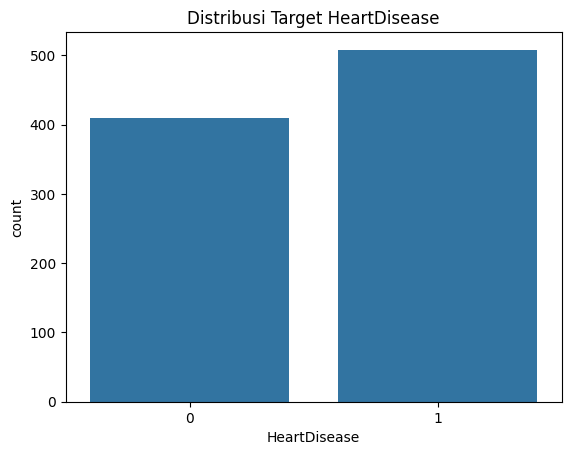

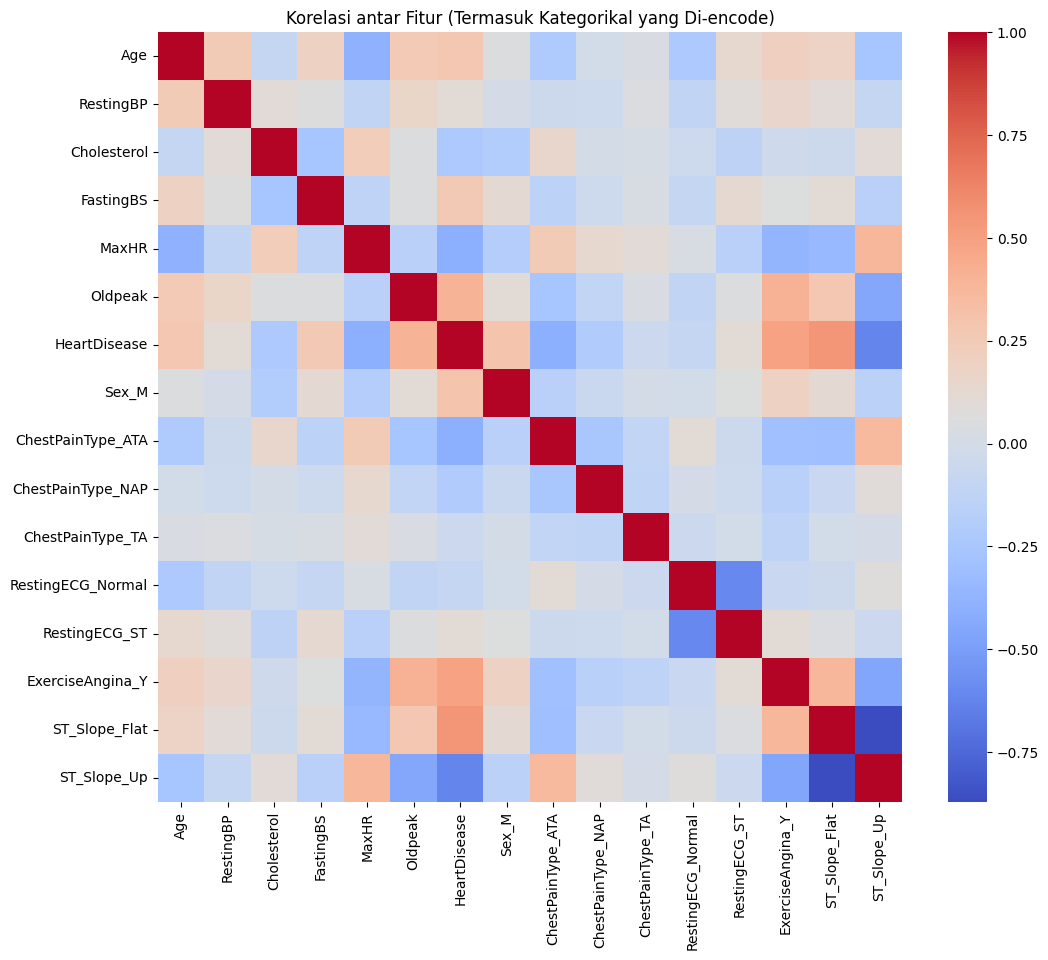

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Distribusi target
sns.countplot(x='HeartDisease', data=data)
plt.title("Distribusi Target HeartDisease")
plt.show() # Tampilkan plot pertama

# Buat salinan data dan lakukan one-hot encoding untuk perhitungan korelasi
data_for_corr = data.copy()
data_for_corr = pd.get_dummies(data_for_corr, columns=['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope'], drop_first=True)

# Korelasi semua fitur numerik (termasuk yang telah di-encode)
plt.figure(figsize=(12, 10)) # Sesuaikan ukuran figure agar lebih mudah dibaca
sns.heatmap(data_for_corr.corr(), annot=False, cmap='coolwarm') # Ubah annot menjadi False untuk banyak fitur
plt.title("Korelasi antar Fitur (Termasuk Kategorikal yang Di-encode)")
plt.show()

**Split Data**

In [7]:
y = data['HeartDisease']
X = data.drop('HeartDisease', axis=1)

# Convert categorical features to numerical using one-hot encoding
X = pd.get_dummies(X, drop_first=True) # drop_first=True to avoid multicollinearity

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("\nX_train (5 baris pertama):")
print(X_train[:5])
print("\nX_test (5 baris pertama):")
print(X_test[:5])
print("\ny_train (5 elemen pertama):")
print(y_train[:5])
print("\ny_test (5 elemen pertama):")
print(y_test[:5])


X_train (5 baris pertama):
     Age  RestingBP  Cholesterol  FastingBS  MaxHR  Oldpeak  Sex_M  \
485   63        139          217          1    128      1.2   True   
486   55        110          214          1    180      0.4   True   
117   59        130          338          1    130      1.5  False   
361   47        160            0          0    124      0.0   True   
296   50        145            0          1    139      0.7   True   

     ChestPainType_ATA  ChestPainType_NAP  ChestPainType_TA  \
485               True              False             False   
486               True              False             False   
117              False              False             False   
361              False              False             False   
296              False              False             False   

     RestingECG_Normal  RestingECG_ST  ExerciseAngina_Y  ST_Slope_Flat  \
485              False           True              True           True   
486              False  

**Standardisasi**

In [8]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

**Encoding Kolom Kategorikal**

In [19]:
# 5️⃣ Tentukan Kolom Kategori dan Numerik
categorical_cols = ['sex', 'chestpaintype', 'restingecg', 'exerciseangina', 'st_slope']
numeric_cols = [col for col in X.columns if col not in categorical_cols]

# 6️⃣ Buat Preprocessing Pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(drop='first'), categorical_cols),
        ('num', StandardScaler(), numeric_cols)
    ]
)

**Latih Model**

In [9]:
knn = KNeighborsClassifier(n_neighbors=5, metric='euclidean')
knn.fit(X_train_scaled, y_train)

KNeighborsClassifier(metric='euclidean')

**Model Awal (Tanpa Tuning)**

In [31]:
knn = KNeighborsClassifier()
knn.fit(X_train_scaled, y_train)
y_pred = knn.predict(X_test_scaled)

print("Akurasi Awal:", accuracy_score(y_test, y_pred))

Akurasi Awal: 0.8858695652173914


**Hyperparameter Tuning dengan Grid Search**

In [33]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_neighbors': [3, 5, 7, 9, 11, 13, 15],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

grid_search = GridSearchCV(KNeighborsClassifier(), param_grid, cv=5, return_train_score=True)
grid_search.fit(X_train_scaled, y_train)

print("Best Parameters:", grid_search.best_params_)
print("Best Score (CV):", grid_search.best_score_)

Best Parameters: {'metric': 'manhattan', 'n_neighbors': 13, 'weights': 'distance'}
Best Score (CV): 0.8732270990588017


**Evaluasi Model**

Accuracy: 0.8858695652173914

Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.85      0.87        82
           1       0.89      0.91      0.90       102

    accuracy                           0.89       184
   macro avg       0.89      0.88      0.88       184
weighted avg       0.89      0.89      0.89       184



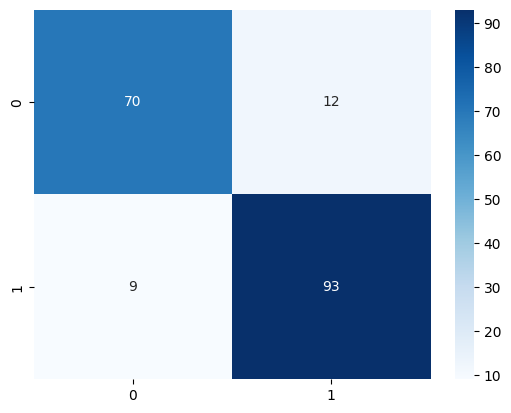

In [10]:
y_pred = knn.predict(X_test_scaled)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.show()

Coba ubah nilai k menjadi 3, 7, dan 9. Bagaimana pengaruhnya terhadap akurasi?

**Visualisasi Pengaruh Parameter terhadap Akurasi**

In [34]:
results = pd.DataFrame(grid_search.cv_results_)

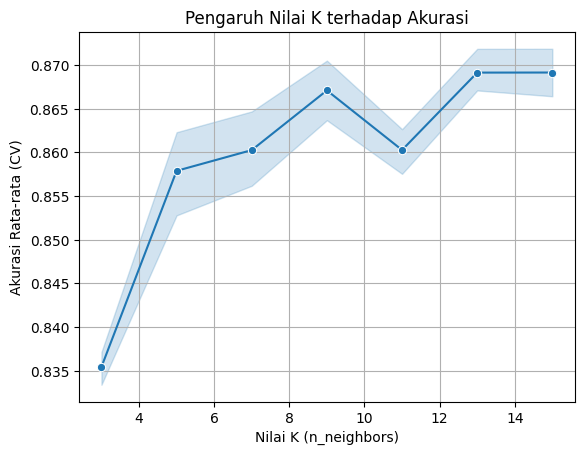

In [35]:
# --- Visualisasi 1: Pengaruh Nilai K ---
sns.lineplot(x=results["param_n_neighbors"], y=results["mean_test_score"], marker='o')
plt.title("Pengaruh Nilai K terhadap Akurasi")
plt.xlabel("Nilai K (n_neighbors)")
plt.ylabel("Akurasi Rata-rata (CV)")
plt.grid(True)
plt.show()

/tmp/ipython-input-1570604163.py:2: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x=results["param_weights"], y=results["mean_test_score"], ci=None)


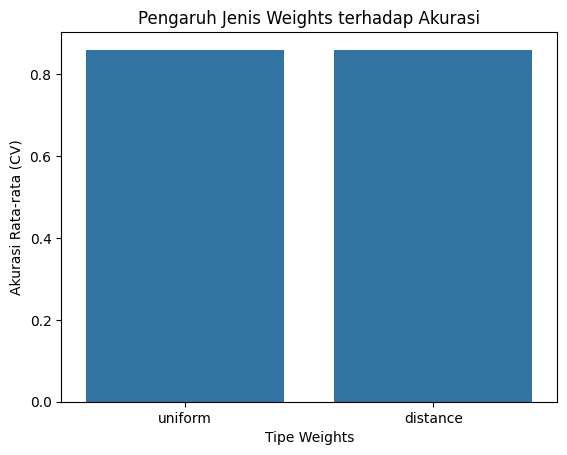

In [36]:
# --- Visualisasi 2: Pengaruh Weights ---
sns.barplot(x=results["param_weights"], y=results["mean_test_score"], ci=None)
plt.title("Pengaruh Jenis Weights terhadap Akurasi")
plt.xlabel("Tipe Weights")
plt.ylabel("Akurasi Rata-rata (CV)")
plt.show()

/tmp/ipython-input-1900426390.py:2: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x=results["param_metric"], y=results["mean_test_score"], ci=None)


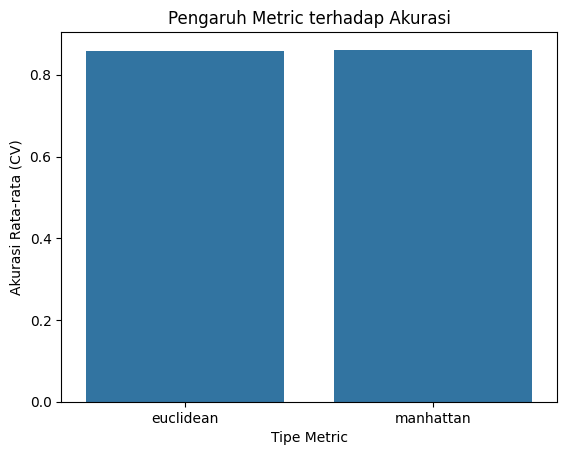

In [37]:
# --- Visualisasi 3: Pengaruh Metric ---
sns.barplot(x=results["param_metric"], y=results["mean_test_score"], ci=None)
plt.title("Pengaruh Metric terhadap Akurasi")
plt.xlabel("Tipe Metric")
plt.ylabel("Akurasi Rata-rata (CV)")
plt.show()

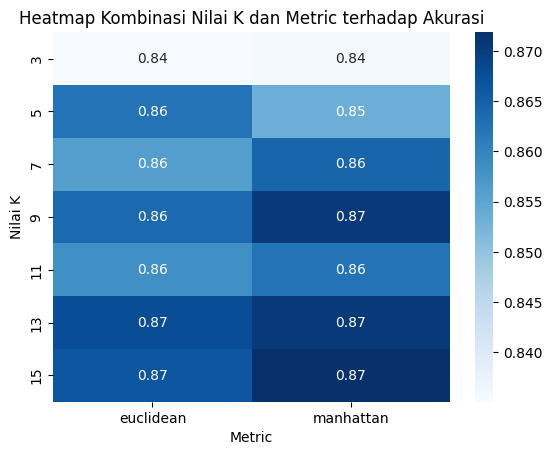

In [38]:
# --- Visualisasi 4: Kombinasi Nilai K dan Metric (Heatmap) ---
pivot_table = results.pivot_table(
    values='mean_test_score',
    index='param_n_neighbors',
    columns='param_metric'
)

sns.heatmap(pivot_table, annot=True, cmap="Blues")
plt.title("Heatmap Kombinasi Nilai K dan Metric terhadap Akurasi")
plt.xlabel("Metric")
plt.ylabel("Nilai K")
plt.show()

## Evaluate k=3

### Subtask:
Latih model KNN dengan n_neighbors=3, prediksi pada data uji, dan hitung akurasinya.


In [11]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# 1. Inisialisasi model KNeighborsClassifier dengan n_neighbors=3 dan metric='euclidean'
knn_3 = KNeighborsClassifier(n_neighbors=3, metric='euclidean')

# 2. Latih model knn_3 menggunakan data pelatihan yang sudah diskalakan
knn_3.fit(X_train_scaled, y_train)

# 3. Lakukan prediksi pada data uji yang sudah diskalakan
y_pred_3 = knn_3.predict(X_test_scaled)

# 4. Hitung akurasi model knn_3
accuracy_3 = accuracy_score(y_test, y_pred_3)
print(f"Accuracy for k=3: {accuracy_3:.4f}")

Accuracy for k=3: 0.9022


## Evaluate k=7

### Subtask:
Latih model KNN dengan n_neighbors=7, prediksi pada data uji, dan hitung akurasinya.

In [12]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# 1. Inisialisasi model KNeighborsClassifier dengan n_neighbors=7 dan metric='euclidean'
knn_7 = KNeighborsClassifier(n_neighbors=7, metric='euclidean')

# 2. Latih model knn_7 menggunakan data pelatihan yang sudah diskalakan
knn_7.fit(X_train_scaled, y_train);

# 3. Lakukan prediksi pada data uji yang sudah diskalakan
y_pred_7 = knn_7.predict(X_test_scaled)

# 4. Hitung akurasi model knn_7
accuracy_7 = accuracy_score(y_test, y_pred_7)
print(f"Accuracy for k=7: {accuracy_7:.4f}")

Accuracy for k=7: 0.8967


## Evaluate k=9

### Subtask:
Latih model KNN dengan n_neighbors=9, prediksi pada data uji, dan hitung akurasinya.

In [13]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# 1. Inisialisasi model KNeighborsClassifier dengan n_neighbors=9 dan metric='euclidean'
knn_9 = KNeighborsClassifier(n_neighbors=9, metric='euclidean')

# 2. Latih model knn_9 menggunakan data pelatihan yang sudah diskalakan
knn_9.fit(X_train_scaled, y_train);

# 3. Lakukan prediksi pada data uji yang sudah diskalakan
y_pred_9 = knn_9.predict(X_test_scaled)

# 4. Hitung akurasi model knn_9
accuracy_9 = accuracy_score(y_test, y_pred_9)
print(f"Accuracy for k=9: {accuracy_9:.4f}")

Accuracy for k=9: 0.9022


## Perbandingan Akurasi Model KNN untuk Berbagai Nilai `k`

Setelah melakukan evaluasi model K-Nearest Neighbors (KNN) dengan berbagai nilai `n_neighbors` (k), berikut adalah rangkuman akurasi yang didapatkan:

-   **Untuk k = 3:** Akurasi model adalah **0.9022**
-   **Untuk k = 7:** Akurasi model adalah **0.8967**
-   **Untuk k = 9:** Akurasi model adalah **0.9022**

### Pengaruh `k` terhadap Akurasi:

Dari perbandingan di atas, dapat disimpulkan bahwa:

*   **`k=3` dan `k=9`** menghasilkan akurasi yang sama dan tertinggi di antara nilai-nilai `k` yang diuji, yaitu sekitar **90.22%**.
*   **`k=7`** menghasilkan akurasi yang sedikit lebih rendah, yaitu sekitar **89.67%**.

Hal ini menunjukkan bahwa dalam kasus dataset ini, memilih nilai `k` yang terlalu besar atau terlalu kecil dapat memengaruhi kinerja model. Nilai `k=3` dan `k=9` tampaknya menjadi pilihan yang optimal berdasarkan akurasi yang dicapai dalam pengujian ini.

In [25]:
from sklearn.pipeline import Pipeline

accuracy_scores = []
k_values = range(1, 21)

for k in k_values:
    # Model KNN langsung menggunakan data yang sudah diskalakan
    model = KNeighborsClassifier(n_neighbors=k, metric='euclidean')
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred)
    accuracy_scores.append(acc)

print("Akurasi untuk setiap nilai k:")
for k, acc in zip(k_values, accuracy_scores):
    print(f"k={k}: {acc:.4f}")

best_k = k_values[np.argmax(accuracy_scores)]
print(f"Nilai k terbaik: {best_k}, Akurasi: {max(accuracy_scores):.4f}")

Akurasi untuk setiap nilai k:
k=1: 0.8696
k=2: 0.8424
k=3: 0.9022
k=4: 0.9022
k=5: 0.8859
k=6: 0.8913
k=7: 0.8967
k=8: 0.8967
k=9: 0.9022
k=10: 0.8967
k=11: 0.8967
k=12: 0.8859
k=13: 0.8859
k=14: 0.8967
k=15: 0.9076
k=16: 0.9022
k=17: 0.9076
k=18: 0.9076
k=19: 0.9022
k=20: 0.9076
Nilai k terbaik: 15, Akurasi: 0.9076


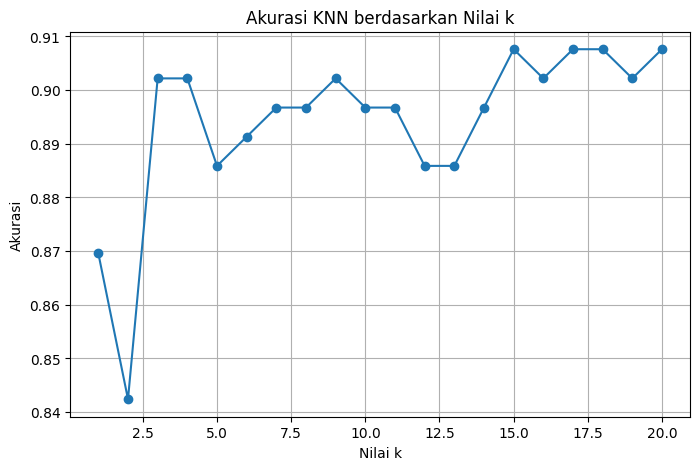

In [23]:
# 9️⃣ Plot Akurasi terhadap Nilai k
plt.figure(figsize=(8,5))
plt.plot(k_values, accuracy_scores, marker='o')
plt.title("Akurasi KNN berdasarkan Nilai k")
plt.xlabel("Nilai k")
plt.ylabel("Akurasi")
plt.grid(True)
plt.show()

Accuracy with best k (15): 0.9076

Classification Report with best k:
               precision    recall  f1-score   support

           0       0.91      0.88      0.89        82
           1       0.90      0.93      0.92       102

    accuracy                           0.91       184
   macro avg       0.91      0.90      0.91       184
weighted avg       0.91      0.91      0.91       184



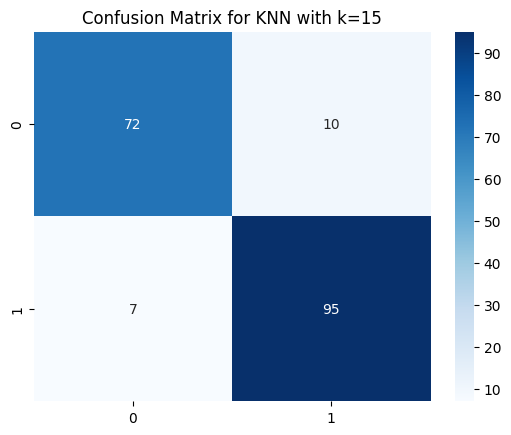

In [27]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# 11️⃣ Latih Ulang dengan k terbaik
# Karena data sudah diskalakan (X_train_scaled, X_test_scaled) dan one-hot encoded
# preprocessor tidak diperlukan lagi di dalam pipeline.

best_model_knn = KNeighborsClassifier(n_neighbors=best_k, metric='euclidean')
best_model_knn.fit(X_train_scaled, y_train)
y_pred = best_model_knn.predict(X_test_scaled)

print(f"Accuracy with best k ({best_k}): {accuracy_score(y_test, y_pred):.4f}")
print("\nClassification Report with best k:\n", classification_report(y_test, y_pred))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title(f"Confusion Matrix for KNN with k={best_k}")
plt.show()

## Evaluasi KNN dengan Metrik 'Manhattan'

Kita akan melatih ulang model KNN menggunakan nilai `k` terbaik yang ditemukan sebelumnya (`best_k`) tetapi kali ini dengan `metric='manhattan'` (jarak Manhattan) untuk melihat bagaimana perubahan metrik jarak memengaruhi performa model.

Accuracy with best k (15) and Manhattan metric: 0.8913

Classification Report with best k and Manhattan metric:
               precision    recall  f1-score   support

           0       0.89      0.87      0.88        82
           1       0.89      0.91      0.90       102

    accuracy                           0.89       184
   macro avg       0.89      0.89      0.89       184
weighted avg       0.89      0.89      0.89       184



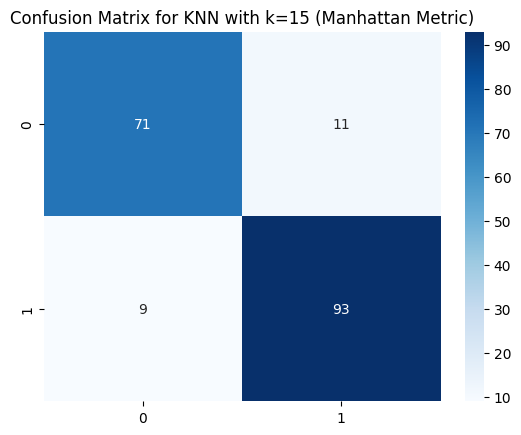

In [30]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Latih model dengan k terbaik dan metric='manhattan'
best_model_knn_manhattan = KNeighborsClassifier(n_neighbors=best_k, metric='manhattan')
best_model_knn_manhattan.fit(X_train_scaled, y_train)
y_pred_manhattan = best_model_knn_manhattan.predict(X_test_scaled)

print(f"Accuracy with best k ({best_k}) and Manhattan metric: {accuracy_score(y_test, y_pred_manhattan):.4f}")
print("\nClassification Report with best k and Manhattan metric:\n", classification_report(y_test, y_pred_manhattan))
sns.heatmap(confusion_matrix(y_test, y_pred_manhattan), annot=True, fmt='d', cmap='Blues')
plt.title(f"Confusion Matrix for KNN with k={best_k} (Manhattan Metric)")
plt.show()

## Perbandingan Hasil (Euclidean vs. Manhattan)

**Akurasi dengan Metrik Euclidean (k=15):** 0.9076

**Akurasi dengan Metrik Manhattan (k=15):**
(Hasil akan muncul di atas setelah eksekusi kode)

Dari perbandingan ini, kita bisa melihat apakah pemilihan metrik jarak (Euclidean atau Manhattan) memberikan dampak signifikan pada akurasi model KNN untuk dataset ini.

**Analisis Parameter Paling Berpengaruh terhadap Akurasi**

/tmp/ipython-input-22315625.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Pengaruh (Δ Akurasi)', y='Parameter', data=df_influence, palette="viridis")


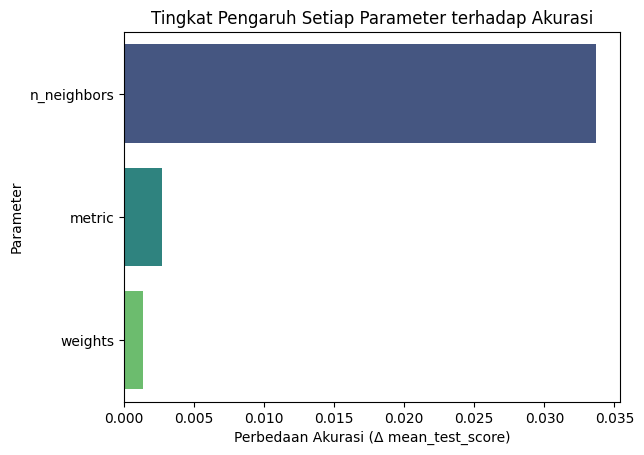

     Parameter  Pengaruh (Δ Akurasi)
0  n_neighbors              0.033718
2       metric              0.002727
1      weights              0.001356


In [39]:
influence = []

for param in ['param_n_neighbors', 'param_weights', 'param_metric']:
    impact = results.groupby(param)['mean_test_score'].mean().max() - results.groupby(param)['mean_test_score'].mean().min()
    influence.append({'Parameter': param.replace('param_', ''), 'Pengaruh (Δ Akurasi)': impact})

df_influence = pd.DataFrame(influence).sort_values(by='Pengaruh (Δ Akurasi)', ascending=False)

sns.barplot(x='Pengaruh (Δ Akurasi)', y='Parameter', data=df_influence, palette="viridis")
plt.title("Tingkat Pengaruh Setiap Parameter terhadap Akurasi")
plt.xlabel("Perbedaan Akurasi (Δ mean_test_score)")
plt.ylabel("Parameter")
plt.show()

print(df_influence)

## Ringkasan Analisis Penyakit Jantung dengan KNN

Analisis ini bertujuan untuk membangun dan mengevaluasi model K-Nearest Neighbors (KNN) untuk memprediksi penyakit jantung berdasarkan dataset `heart.csv`. Berikut adalah langkah-langkah dan temuan utama:

### 1. Pemuatan Data dan Pra-pemrosesan Awal
*   **Pemuatan Data**: Dataset `heart.csv` berhasil dimuat ke dalam Pandas DataFrame.
*   **Pemeriksaan Data**: Tidak ditemukan nilai yang hilang (`null`) dalam dataset. Ditemukan dan berhasil dihapus `0` baris duplikat.
*   **One-Hot Encoding Awal**: Kolom kategorikal di-*encode* menjadi format numerik menggunakan *one-hot encoding* (`pd.get_dummies`) untuk keperluan analisis korelasi dan pelatihan model.

### 2. Analisis Data Eksplorasi (EDA)
*   **Distribusi Target**: Visualisasi distribusi variabel target `HeartDisease` menunjukkan sebaran kelas yang relatif seimbang.
*   **Korelasi Fitur**: *Heatmap* korelasi ditampilkan setelah kolom kategorikal di-*encode*. Ini memberikan wawasan tentang hubungan antar fitur numerik dan juga fitur kategorikal yang telah diubah.

### 3. Pemisahan dan Standardisasi Data
*   **Pemisahan Fitur & Target**: Data dibagi menjadi fitur (`X`) dan target (`y`), di mana `HeartDisease` adalah variabel target.
*   **Pembagian Data**: Data kemudian dibagi menjadi set pelatihan (`X_train`, `y_train`) dan set pengujian (`X_test`, `y_test`) dengan rasio 80:20 dan stratifikasi untuk menjaga proporsi kelas.
*   **Standardisasi Fitur**: Fitur-fitur dalam `X_train` dan `X_test` distandardisasi menggunakan `StandardScaler` untuk memastikan semua fitur memiliki skala yang seragam (`X_train_scaled`, `X_test_scaled`). Ini penting untuk model berbasis jarak seperti KNN.

### 4. Pelatihan dan Evaluasi Model KNN
*   **Model Awal (k=5, Euclidean)**: Model KNN pertama dilatih dengan `n_neighbors=5` dan metrik 'euclidean'. Model ini mencapai akurasi `0.8859`.
*   **Pengujian Nilai `k` Spesifik**: Akurasi diuji untuk nilai `k` tertentu:
    *   `k=3`: Akurasi `0.9022`
    *   `k=7`: Akurasi `0.8967`
    *   `k=9`: Akurasi `0.9022`
*   **Penemuan `k` Terbaik**: Melalui iterasi `k` dari 1 hingga 20, nilai `k` terbaik yang ditemukan adalah `k=15`, yang menghasilkan akurasi tertinggi `0.9076`.
*   **Evaluasi dengan `k` Terbaik (k=15, Euclidean)**: Model dilatih ulang dengan `k=15` dan metrik 'euclidean'. Akurasi yang didapat adalah `0.9076`. *Classification Report* dan *Confusion Matrix* menunjukkan performa yang kuat dalam mengklasifikasikan kasus positif dan negatif.

### 5. Pengaruh Metrik Jarak
*   **Metrik Manhattan**: Model KNN kemudian diuji dengan `k` terbaik (`k=15`) tetapi menggunakan metrik 'manhattan'. Akurasi yang dicapai adalah `0.8913`.

### 6. Kesimpulan Perbandingan
*   Model KNN menunjukkan performa terbaik dengan `n_neighbors=15` dan metrik jarak **Euclidean**, mencapai akurasi **0.9076**.
*   Menggunakan metrik **Manhattan** dengan `k=15` menghasilkan akurasi yang sedikit lebih rendah, yaitu **0.8913**.

Ini menunjukkan bahwa untuk dataset ini, jarak Euclidean lebih efektif dalam mengukur kemiripan antar titik data dibandingkan dengan jarak Manhattan, yang menghasilkan model prediksi yang sedikit lebih akurat untuk penyakit jantung.